In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [25]:
attack_df = pd.read_csv("../data/clean_data/modeling_data.csv")
attack_df = attack_df[attack_df["activity"] != "adrift"]
# attack_df.drop(["country", "time", "month", "hemisphere", "species"], axis=1, inplace=True)
print(f"Num attacks: {len(attack_df)}")

attack_df.head()

Num attacks: 3358


,country,state,activity,fatal,time,species,month,hemisphere,season
0,usa,florida,swimming,N,morning,NaN,6.0,northern,summer
1,australia,new south wales,swimming,N,morning,great white,6.0,southern,winter
2,usa,florida,swimming,N,morning,bull,6.0,northern,summer
3,australia,western australia,dive fishing,Y,morning,great white,6.0,southern,winter
4,australia,new south wales,surfing/bodyboarding,N,evening,bull,5.0,southern,fall


In [39]:
# function to plate fatality rates by different attributes
def fatality_rate_plots(fatal_counts_df, prop_fatal, attribute_name: str, max_x=1400, legend_pos="lower right", title="NULL"):

    fig, axes = plt.subplots(1, 2, figsize=(12,4), gridspec_kw={'wspace': 0.1})

    title_word = attribute_name.capitalize()

    # bar chart for totals
    b1 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["nonfatal_count"],
        label="nonfatal"
    )
    b2 = axes[0].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatal_count"],
        label="fatal"
    )
    axes[0].bar_label(axes[0].containers[0], labels=fatal_counts_df["total_count"], padding=3)
    axes[0].set_xlim(0, max_x)
    axes[0].legend(loc=legend_pos)


    # bar chart for death rates
    b3 = axes[1].barh(
        fatal_counts_df[attribute_name],
        fatal_counts_df["fatality_rate"],
        color="gray"
    )
    plt.axvline(x=prop_fatal, color='red', linestyle='--', linewidth=2, label='Overall Fatality Rate')
    axes[1].bar_label(axes[1].containers[0], fmt='%.3f', padding=4)
    axes[1].set_yticks([])
    axes[1].set_xlim(0, 0.5)
    axes[1].legend()


    # set labels and titles
    axes[0].set_ylabel(title_word, fontsize=13)
    axes[0].set_xlabel("Attack Count", fontsize=13)
    axes[1].set_xlabel("Fatality Rate", fontsize=13)
    fig.suptitle(title, fontsize=16)

    plt.savefig(f"../figures/fatrate_plots_{attribute_name}.png", dpi=300, bbox_inches="tight")
    plt.show()


def prep_for_viz(df, var_name):

    total_attacks = len(df)

    nonfatal_df = df[df["fatal"] == "N"]
    fatal_df = df[df["fatal"] == "Y"]

    counts1 = fatal_df.groupby(var_name).size().to_frame(name="fatal_count").reset_index()
    counts2 = nonfatal_df.groupby(var_name).size().to_frame(name="nonfatal_count").reset_index()

    counts = counts2.merge(counts1, on=var_name, how="left").fillna(0)
    counts["total_count"] = counts["fatal_count"] + counts["nonfatal_count"]
    counts["fatality_rate"] = counts["fatal_count"] / counts["total_count"]

    counts.sort_values("total_count", ascending=True, inplace=True)

    return counts, prop_fatal

## 

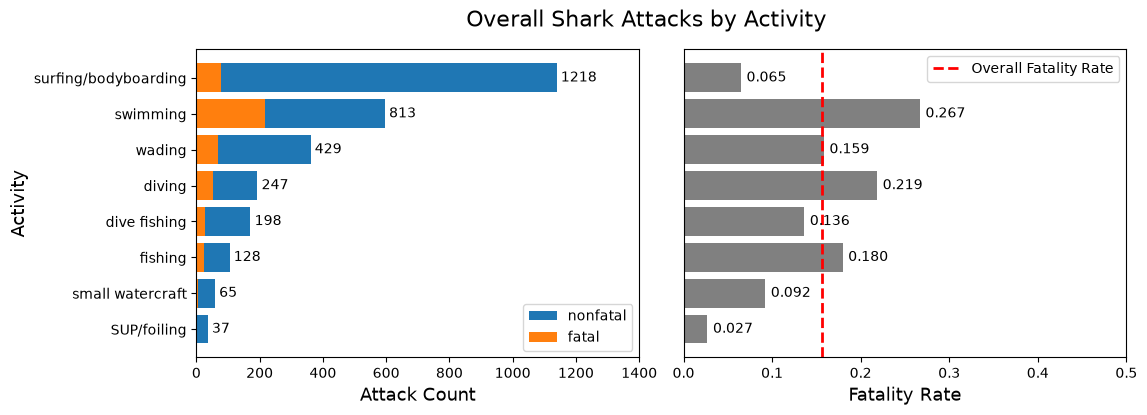

In [40]:
all_attacks, prop_fatal = prep_for_viz(attack_df, "activity")
fatality_rate_plots(all_attacks, attribute_name="activity", prop_fatal=prop_fatal, title="Overall Shark Attacks by Activity")

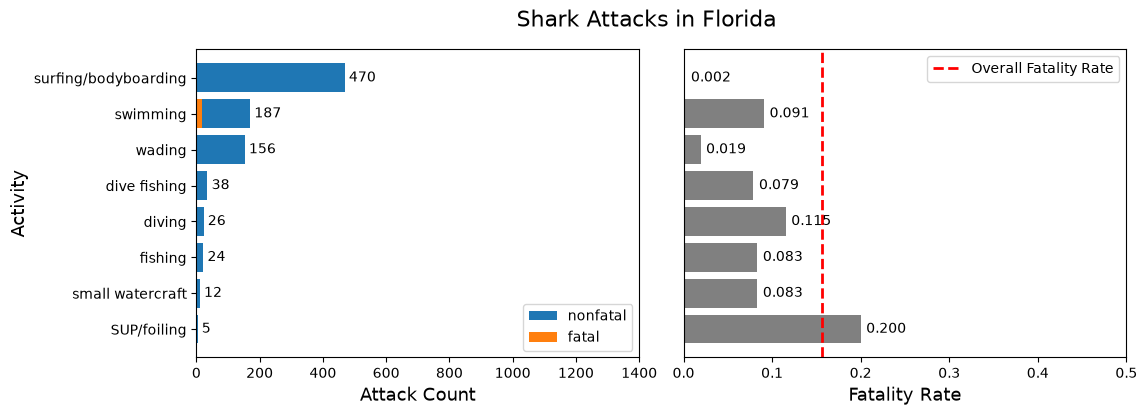

In [41]:
fl_attacks = attack_df[attack_df["state"] == "florida"]
other_attacks = attack_df[attack_df["state"] != "florida"]

fl_attacks, florida_prop = prep_for_viz(fl_attacks, "activity")
fatality_rate_plots(fl_attacks, attribute_name="activity", prop_fatal=florida_prop, title="Shark Attacks in Florida")

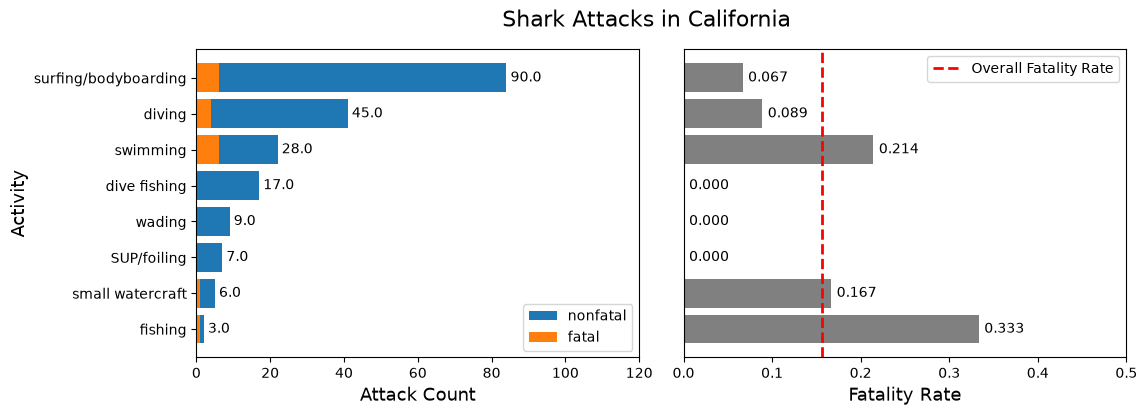

In [44]:
ca_attacks = attack_df[attack_df["state"] == "california"]
other_attacks = attack_df[attack_df["state"] != "california"]

ca_attacks, ca_prop = prep_for_viz(ca_attacks, "activity")
fatality_rate_plots(ca_attacks, attribute_name="activity", prop_fatal=ca_prop, title="Shark Attacks in California", max_x = 120)

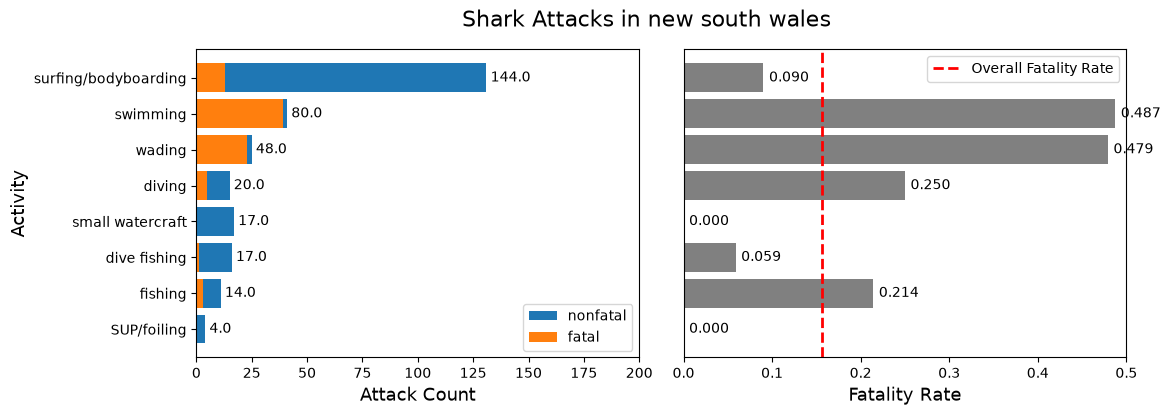

In [47]:
nsw_attacks = attack_df[attack_df["state"] == "new south wales"]
other_attacks = attack_df[attack_df["state"] != "new south wales"]

nsw_attacks, nsw_prop = prep_for_viz(nsw_attacks, "activity")
fatality_rate_plots(nsw_attacks, attribute_name="activity", prop_fatal=nsw_prop, title="Shark Attacks in new south wales", max_x = 200)

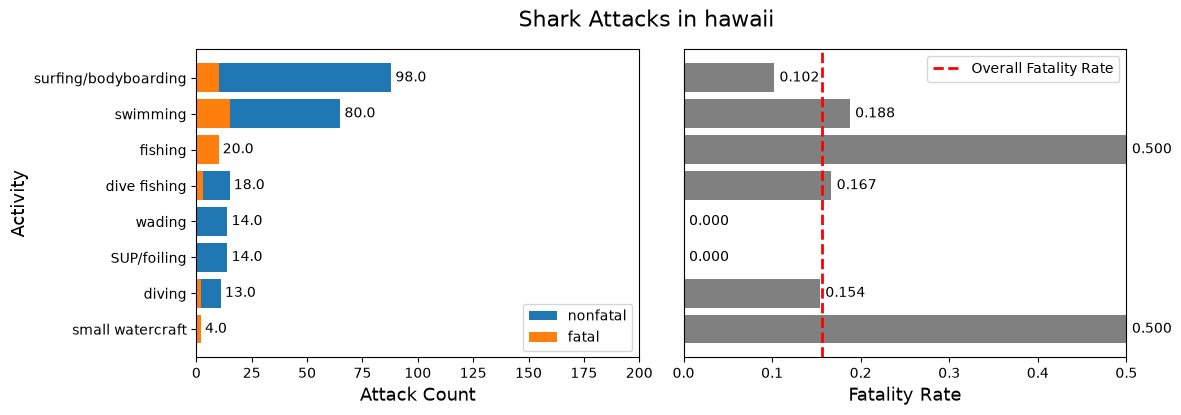

In [48]:
hi_attacks = attack_df[attack_df["state"] == "hawaii"]
other_attacks = attack_df[attack_df["state"] != "hawaii"]

hi_attacks, hi_prop = prep_for_viz(hi_attacks, "activity")
fatality_rate_plots(hi_attacks, attribute_name="activity", prop_fatal=hi_prop, title="Shark Attacks in hawaii", max_x = 200)

# Season